In [2]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: C:\Users\admin\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


## 1. Import libraries

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Create a demonstration dataset

In [5]:
# Synthetic data generated for this project; no real student information is used.
n = 1000
study_hours = np.clip(np.random.normal(2.8, 1.4, n), 0, 8)
attendance = np.clip(np.random.normal(78, 13, n), 35, 100)
assignment_completion = np.clip(np.random.normal(76, 18, n), 0, 100)
previous_score = np.clip(np.random.normal(65, 15, n), 10, 100)
sleep_hours = np.clip(np.random.normal(7, 1.1, n), 3, 10)
screen_time = np.clip(np.random.normal(4.5, 1.7, n), 0.5, 10)

# A transparent simulated rule plus noise creates a plausible target.
risk_score = (
    0.9 * (study_hours < 2.0).astype(int)
    + 1.0 * (attendance < 65).astype(int)
    + 0.8 * (assignment_completion < 60).astype(int)
    + 0.9 * (previous_score < 50).astype(int)
    + 0.25 * (sleep_hours < 5.5).astype(int)
    + np.random.normal(0, 0.55, n)
)
at_risk = (risk_score >= 1.65).astype(int)

df = pd.DataFrame({
    "study_hours_per_day": study_hours.round(1),
    "attendance_percent": attendance.round(1),
    "assignment_completion_percent": assignment_completion.round(1),
    "previous_score": previous_score.round(1),
    "sleep_hours": sleep_hours.round(1),
    "screen_time_hours": screen_time.round(1),
    "at_risk": at_risk
})
df["risk_label"] = df["at_risk"].map({0: "Lower risk", 1: "At risk"})

print("Dataset shape:", df.shape)
display(df.head())
print("\nTarget distribution:")
display(df["risk_label"].value_counts().to_frame("students"))

Dataset shape: (1000, 8)


,study_hours_per_day,attendance_percent,assignment_completion_percent,previous_score,sleep_hours,screen_time_hours,at_risk,risk_label
0,3.5,96.2,63.8,36.4,6.1,3.8,0,Lower risk
1,2.6,90.0,73.4,52.1,7.0,3.7,0,Lower risk
2,3.7,78.8,61.7,58.8,7.0,1.4,0,Lower risk
3,4.9,69.6,70.5,93.3,7.5,3.9,0,Lower risk
4,2.5,87.1,41.9,73.3,5.5,5.7,0,Lower risk



Target distribution:


,students
risk_label,
Lower risk,845
At risk,155


## 3. Data quality checks

In [6]:
print("Missing values per column:")
display(df.isna().sum().to_frame("missing_values"))
print("Duplicate rows:", df.duplicated().sum())
display(df.describe().round(2))

Missing values per column:


,missing_values
study_hours_per_day,0
attendance_percent,0
assignment_completion_percent,0
previous_score,0
sleep_hours,0
screen_time_hours,0
at_risk,0
risk_label,0


Duplicate rows: 0


,study_hours_per_day,attendance_percent,assignment_completion_percent,previous_score,sleep_hours,screen_time_hours,at_risk
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,2.84,78.65,75.34,64.68,6.94,4.42,0.16
std,1.35,12.41,16.25,15.30,1.09,1.70,0.36
min,0.00,39.80,21.60,21.10,3.50,0.50,0.00
25%,1.90,70.10,64.30,53.90,6.28,3.30,0.00
50%,2.80,78.80,76.00,65.00,7.00,4.40,0.00
75%,3.70,87.50,87.93,75.03,7.70,5.50,0.00
max,8.00,100.00,100.00,100.00,10.00,9.80,1.00


## 4. Exploratory data analysis (EDA)

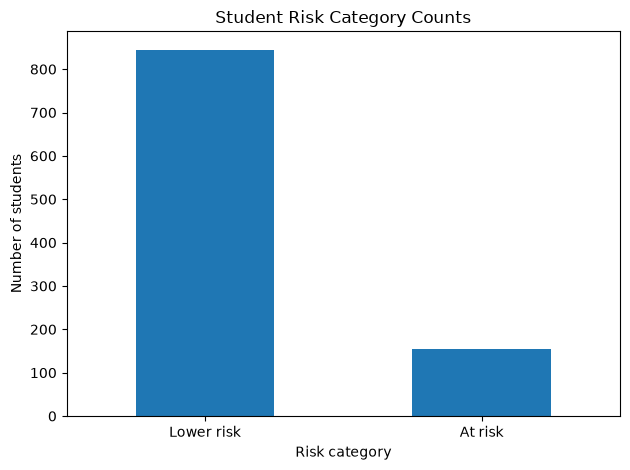

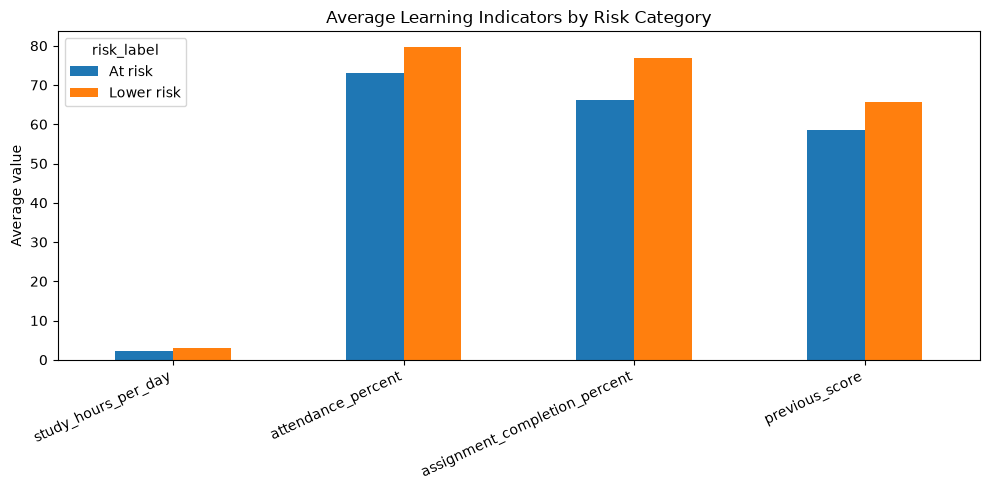

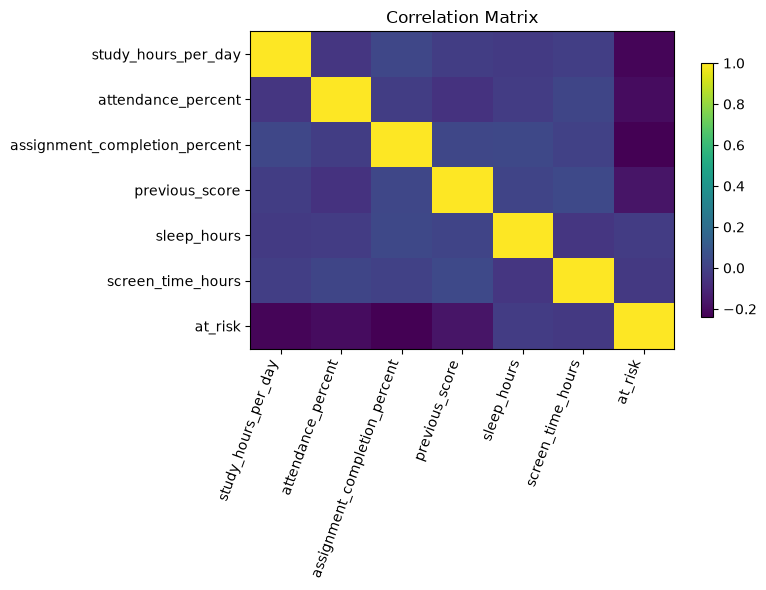

In [7]:
# Distribution of risk labels
df["risk_label"].value_counts().reindex(["Lower risk", "At risk"]).plot(kind="bar")
plt.title("Student Risk Category Counts")
plt.xlabel("Risk category")
plt.ylabel("Number of students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Compare average study habits by risk category
features_for_plot = [
    "study_hours_per_day", "attendance_percent",
    "assignment_completion_percent", "previous_score"
]
group_means = df.groupby("risk_label")[features_for_plot].mean().T
group_means.plot(kind="bar", figsize=(10, 5))
plt.title("Average Learning Indicators by Risk Category")
plt.ylabel("Average value")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# Correlation heatmap using matplotlib only
corr = df.drop(columns=["risk_label"]).corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=70, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
ax.set_title("Correlation Matrix")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 5. Prepare data and train an AI model

In [8]:
X = df.drop(columns=["at_risk", "risk_label"])
y = df["at_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

model = RandomForestClassifier(
    n_estimators=250,
    max_depth=8,
    class_weight="balanced",
    random_state=RANDOM_STATE
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 score": f1_score(y_test, y_pred, zero_division=0)
}
display(pd.DataFrame(metrics.items(), columns=["Metric", "Score"]).round(3))
print(classification_report(y_test, y_pred, target_names=["Lower risk", "At risk"], zero_division=0))

,Metric,Score
0,Accuracy,0.890
1,Precision,0.714
2,Recall,0.484
3,F1 score,0.577


              precision    recall  f1-score   support

  Lower risk       0.91      0.96      0.94       169
     At risk       0.71      0.48      0.58        31

    accuracy                           0.89       200
   macro avg       0.81      0.72      0.76       200
weighted avg       0.88      0.89      0.88       200



## 6. Evaluate the model

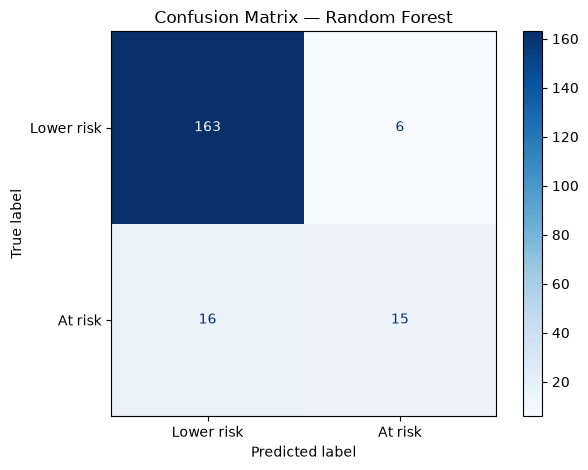

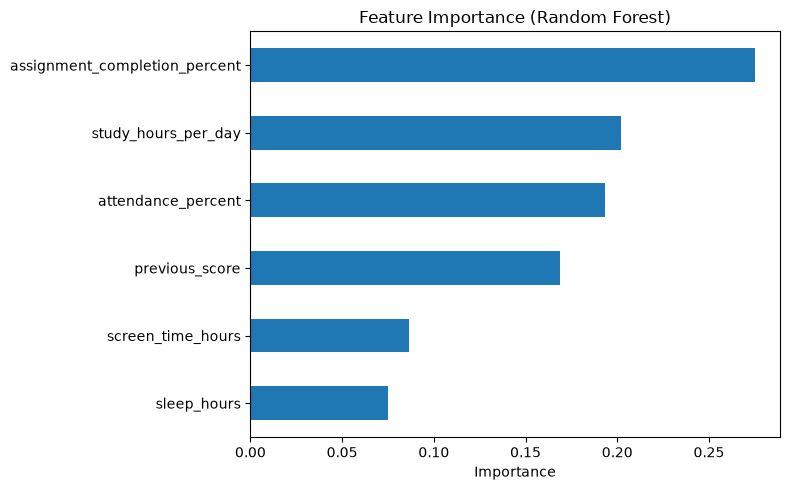

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Lower risk", "At risk"], cmap="Blues"
)
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

importance = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importance.plot(kind="barh", figsize=(8, 5))
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 7. Predict risk for a sample student

In [10]:
sample_student = pd.DataFrame([{
    "study_hours_per_day": 1.5,
    "attendance_percent": 58,
    "assignment_completion_percent": 55,
    "previous_score": 48,
    "sleep_hours": 6.5,
    "screen_time_hours": 5.0
}])

prediction = int(model.predict(sample_student)[0])
probability = float(model.predict_proba(sample_student)[0][1])
label = "At risk" if prediction == 1 else "Lower risk"

print("Predicted category:", label)
print(f"Estimated model probability for 'At risk': {probability:.1%}")
display(sample_student)

Predicted category: At risk
Estimated model probability for 'At risk': 91.1%


,study_hours_per_day,attendance_percent,assignment_completion_percent,previous_score,sleep_hours,screen_time_hours
0,1.5,58,55,48,6.5,5.0
